In [40]:
pip install pandas matplotlib seaborn 

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
# biblioteki
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import csv
import re

sns.set_theme(style="whitegrid", context="notebook")


In [3]:
import numpy as np

##  Tworzenie datasetów

In [5]:
# dataset OpenAlex
df_ap = pd.read_csv('datasets/OpenAlex.csv')
df_ap.head()

,id,abstract,authorships.author.display_name,authorships.author.id,authorships.author.orcid,authorships.countries,authorships.institutions.display_name,authorships.institutions.id,authorships.is_corresponding,best_oa_location.license,...,open_access.is_oa,open_access.oa_status,primary_location.source.display_name,primary_location.source.id,primary_location.source.issn_l,primary_location.source.type,primary_topic.display_name,publication_date,publication_year,type
0,https://openalex.org/W2935921205,NaN,Md Rakibul Hasan|Maisha Maliha|Md. Arifuzzaman,https://openalex.org/A5025876524|https://opena...,https://orcid.org/0000-0003-2565-5321|https://...,BD|BD|BD,East West University|East West University|Bang...,https://openalex.org/I885507782|https://openal...,True|False|False,NaN,...,False,closed,"2019 International Conference on Computer, Com...",https://openalex.org/S4306498525,NaN,conference,Sentiment Analysis and Opinion Mining,2019-07-01,2019.0,article
1,https://openalex.org/W2006724638,NaN,Monisha Kanakaraj|Ram Mohana Reddy Guddeti,https://openalex.org/A5083180185|https://opena...,|https://orcid.org/0000-0003-1361-3837,IN|IN,National Institute of Technology Karnataka|Sar...,https://openalex.org/I11880225|https://openale...,True|False,NaN,...,False,closed,NaN,NaN,NaN,NaN,Sentiment Analysis and Opinion Mining,2015-02-01,2015.0,article
2,https://openalex.org/W3082506307,"Abstract In this exploratory study, we scrutin...",Abraham Sanders|Rachael C. White|Lauren S. Sev...,https://openalex.org/A5006336193|https://opena...,https://orcid.org/0000-0002-5231-2239||||||htt...,US|US|US|US|US|US|US|US|US,Rensselaer Polytechnic Institute|Rensselaer Po...,https://openalex.org/I165799507|https://openal...,True|False|False|False|False|False|False|False...,cc-by-nc,...,True,gold,NaN,NaN,NaN,NaN,Misinformation and Its Impacts,2020-09-01,2020.0,preprint
3,https://openalex.org/W1556110137,NaN,Monisha Kanakaraj|Ram Mohana Reddy Guddeti,https://openalex.org/A5083180185|https://opena...,|https://orcid.org/0000-0003-1361-3837,IN|IN,National Institute of Technology Karnataka|Nat...,https://openalex.org/I11880225|https://openale...,True|False,NaN,...,False,closed,NaN,NaN,NaN,NaN,Sentiment Analysis and Opinion Mining,2015-03-01,2015.0,article
4,https://openalex.org/W3176969785,The pandemic has taken the world by storm. Alm...,F. M. Javed Mehedi Shamrat|Sovon Chakraborty|M...,https://openalex.org/A5045615699|https://opena...,https://orcid.org/0000-0001-9176-3537|https://...,BD|BD||BD|BD|BD|BD,Daffodil International University|European Uni...,https://openalex.org/I200606013|https://openal...,True|False|False|False|False|False|False,NaN,...,True,diamond,Indonesian Journal of Electrical Engineering a...,https://openalex.org/S2764855249,2502-4752,journal,Sentiment Analysis and Opinion Mining,2021-07-01,2021.0,article


In [7]:
print(df_ap.columns)

Index(['id', 'abstract', 'authorships.author.display_name',
       'authorships.author.id', 'authorships.author.orcid',
       'authorships.countries', 'authorships.institutions.display_name',
       'authorships.institutions.id', 'authorships.is_corresponding',
       'best_oa_location.license', 'cited_by_count',
       'corresponding_institution_ids', 'display_name', 'doi',
       'funders.display_name', 'fwci', 'ids.pmid', 'is_retracted', 'language',
       'open_access.is_oa', 'open_access.oa_status',
       'primary_location.source.display_name', 'primary_location.source.id',
       'primary_location.source.issn_l', 'primary_location.source.type',
       'primary_topic.display_name', 'publication_date', 'publication_year',
       'type'],
      dtype='object')


In [9]:
#dateset Scopus

df_sc = pd.read_csv('datasets/scopus_export_Mar 19-2026.csv')
df_sc.head()

,Authors,Author full names,Author(s) ID,Title,Year,Source title,Volume,Issue,Art. No.,Page start,...,ISBN,CODEN,PubMed ID,Language of Original Document,Abbreviated Source Title,Document Type,Publication Stage,Open Access,Source,EID
0,Mathuna K.T.; Elizabeth Shanthi I.,"Mathuna, K.T. (57224455212); Elizabeth Shanthi...",57224455212; 56584405200,Advanced Sentiment Analysis in Health Care Usi...,2025,International Journal of Intelligent Engineeri...,18,11,NaN,229,...,NaN,NaN,NaN,English,Int. J. Intelligent Eng. Syst.,Article,Final,All Open Access; Bronze Open Access,Scopus,2-s2.0-105022247288
1,Dolaeva A.; Beliaeva U.; Grigoriev D.; Semenov...,"Dolaeva, Aishat (57431698100); Beliaeva, Ulian...",57431698100; 59519166400; 56790445200; 5687924...,Analyzing and forecasting P/E ratios using inv...,2025,International Review of Economics and Finance,98,NaN,103840,NaN,...,NaN,NaN,NaN,English,Int. Rev. Econ. Financ.,Article,Final,All Open Access; Gold Open Access; Green Open ...,Scopus,2-s2.0-85215359601
2,Zineddine A.; Rehaimi A.; Zaoui M.; Belfaik Y....,"Zineddine, Abdelhadi (58903756000); Rehaimi, A...",58903756000; 58124315700; 59135430900; 5914201...,LLM-based assessment of HTTPS cybersecurity aw...,2025,Data in Brief,62,NaN,112024,NaN,...,NaN,NaN,NaN,English,Data Brief,Data paper,Final,All Open Access; Gold Open Access; Green Open ...,Scopus,2-s2.0-105015396970
3,Bell V.; White R.; Foulkes L.,"Bell, Vaughan (7007065687); White, Rhiannon (6...",7007065687; 60109705500; 55846111000,Understanding the countermovement to online pr...,2026,Journal of Mental Health,35,1,NaN,25,...,NaN,JMEHE,40938792.0,English,J. Ment. Health,Article,Final,All Open Access; Hybrid Gold Open Access,Scopus,2-s2.0-105016719414
4,Olawade D.B.; Omeni D.; Gore M.N.; Hadi M.,"Olawade, David B. (57219597340); Omeni, Debora...",57219597340; 59932228300; 56677355500; 5719370...,Enhancing qualitative research through virtual...,2025,International Journal of Medical Informatics,203,NaN,106004,NaN,...,NaN,IJMIF,40482393.0,English,Int. J. Med. Informatics,Article,Final,All Open Access; Green Open Access; Hybrid Gol...,Scopus,2-s2.0-105007430511


In [6]:
print(df_sc.columns)

Index(['Authors', 'Author full names', 'Author(s) ID', 'Title', 'Year',
       'Source title', 'Volume', 'Issue', 'Art. No.', 'Page start', 'Page end',
       'Cited by', 'DOI', 'Link', 'Affiliations', 'Authors with affiliations',
       'Abstract', 'Author Keywords', 'Index Keywords',
       'Molecular Sequence Numbers', 'Chemicals/CAS', 'Tradenames',
       'Manufacturers', 'Funding Details', 'Funding Texts', 'References',
       'Correspondence Address', 'Editors', 'Publisher', 'Sponsors',
       'Conference name', 'Conference date', 'Conference location',
       'Conference code', 'ISSN', 'ISBN', 'CODEN', 'PubMed ID',
       'Language of Original Document', 'Abbreviated Source Title',
       'Document Type', 'Publication Stage', 'Open Access', 'Source', 'EID'],
      dtype='object')


In [10]:
# dataset web of science
params = {
    'sep': '\t',
    'quoting': csv.QUOTE_NONE,
    'encoding': 'utf-8', 
    'index_col': False,
    'on_bad_lines': 'warn'
}

files = [
    r'datasets/WebOfScience1-1000.csv',
    r'datasets/WebOfScience1001-2000.csv',
    r'datasets/WebOfScience2001-2100.csv'
]

df_list = []
for f in files:
    temp_df = pd.read_csv(f, **params)
    df_list.append(temp_df)

df_wos = pd.concat(df_list, axis=0, ignore_index=True)


mapping = {
    'FN': 'File Name',
    'VR': 'Version Number',
    'PT': 'Publication Type',
    'AU': 'Authors',
    'AF': 'Author Full Name',
    'BA': 'Book Authors',
    'BF': 'Book Authors Full Name',
    'CA': 'Group Authors',
    'GP': 'Book Group Authors',
    'BE': 'Editors',
    'TI': 'Document Title',
    'SO': 'Publication Name',
    'SE': 'Book Series Title',
    'BS': 'Book Series Subtitle',
    'LA': 'Language',
    'DT': 'Document Type',
    'CT': 'Conference Title',
    'CY': 'Conference Date',
    'CL': 'Conference Location',
    'SP': 'Conference Sponsors',
    'HO': 'Conference Host',
    'DE': 'Author Keywords',
    'ID': 'Keywords Plus®',
    'AB': 'Abstract',
    'C1': 'Author Address',
    'RP': 'Reprint Address',
    'EM': 'E-mail Address',
    'RI': 'ResearcherID Number',
    'OI': 'ORCID Identifier (Open Researcher and Contributor ID)',
    'FU': 'Funding Agency and Grant Number',
    'FX': 'Funding Text',
    'CR': 'Cited References',
    'NR': 'Cited Reference Count',
    'TC': 'Web of Science Core Collection Times Cited Count',
    'Z9': 'Total Times Cited Count',
    'U1': 'Usage Count (Last 180 Days)',
    'U2': 'Usage Count (Since 2013)',
    'PU': 'Publisher',
    'PI': 'Publisher City',
    'PA': 'Publisher Address',
    'SN': 'International Standard Serial Number (ISSN)',
    'EI': 'Electronic International Standard Serial Number (eISSN)',
    'BN': 'International Standard Book Number (ISBN)',
    'J9': '29-Character Source Abbreviation',
    'JI': 'ISO Source Abbreviation',
    'PD': 'Publication Date',
    'PY': 'Year Published',
    'VL': 'Volume',
    'IS': 'Issue',
    'SI': 'Special Issue',
    'PN': 'Part Number',
    'SU': 'Supplement',
    'MA': 'Meeting Abstract',
    'BP': 'Beginning Page',
    'EP': 'Ending Page',
    'AR': 'Article Number',
    'DI': 'Digital Object Identifier (DOI)',
    'D2': 'Book Digital Object Identifier (DOI)',
    'PG': 'Page Count',
    'P2': 'Chapter Count (Book Citation Index)',
    'WC': 'Web of Science Categories',
    'SC': 'Research Areas',
    'GA': 'Document Delivery Number',
    'UT': 'Accession Number',
    'PM': 'PubMed ID',
    'ER': 'End of Record',
    'EF': 'End of File'}


df_wos = df_wos.rename(columns=mapping)

print(f"The file has {len(df_wos)} records.")

The file has 2100 records.


In [ ]:
df_wos.head()

,Publication Type,Authors,Book Authors,Editors,Book Group Authors,Author Full Name,Book Authors Full Name,Group Authors,Document Title,Publication Name,...,Web of Science Categories,WE,Research Areas,Document Delivery Number,PubMed ID,OA,HC,HP,DA,Accession Number
0,J,"Molenaar, A; Jenkins, EL; Brennan, L; Lukose, ...",NaN,NaN,NaN,"Molenaar, Annika; Jenkins, Eva L.; Brennan, Li...",NaN,NaN,The use of sentiment and emotion analysis and ...,NUTRITION RESEARCH REVIEWS,...,Nutrition & Dietetics,Science Citation Index Expanded (SCI-EXPANDED),Nutrition & Dietetics,D9O1H,36991525.0,hybrid,NaN,NaN,2026-03-19,WOS:000973757300001
1,J,"Arya, V; Mishra, AK; González-Briones, A",NaN,NaN,NaN,"Arya, Vishakha; Mishra, Amit Kumar; Gonzalez-B...",NaN,NaN,Analysis of Sentiments on the Onset of COVID-1...,ADCAIJ-ADVANCES IN DISTRIBUTED COMPUTING AND A...,...,"Computer Science, Artificial Intelligence",Emerging Sources Citation Index (ESCI),Computer Science,2D4DX,NaN,"Green Submitted, gold",NaN,NaN,2026-03-19,WOS:000811500900003
2,J,"Albahli, S",NaN,NaN,NaN,"Albahli, Saleh",NaN,NaN,Twitter sentiment analysis: An Arabic text min...,FRONTIERS IN PUBLIC HEALTH,...,"Public, Environmental & Occupational Health",Science Citation Index Expanded (SCI-EXPANDED)...,"Public, Environmental & Occupational Health",5R6QQ,36299761.0,"Green Submitted, gold",NaN,NaN,2026-03-19,WOS:000874633300001
3,J,"Rivadeneira, L; Loor, I",NaN,NaN,NaN,"Rivadeneira, Lucia; Loor, Ignacio",NaN,NaN,X Data-Based Research: A Review of Trends and ...,REVISTA LATINA DE COMUNICACION SOCIAL,...,Communication,Emerging Sources Citation Index (ESCI),Communication,0LE8W,NaN,gold,NaN,NaN,2026-03-19,WOS:001450007300001
4,C,"El Ouahabi, S; El Ouahabi, S; Dadil, E",NaN,"Hagras, H; Bennani, Y; Nemiche, M",NaN,"El Ouahabi, Sara; El Ouahabi, Safaa; Dadil, El...",NaN,NaN,Sentiment Analysis for Moroccan Dialect Using ...,INTELLIGENT SYSTEMS AND ADVANCED COMPUTING SCI...,...,"Computer Science, Artificial Intelligence; Com...",Conference Proceedings Citation Index - Scienc...,Computer Science,BZ3IZ,NaN,NaN,NaN,NaN,2026-03-19,WOS:001562683700004


# Świat

## Chronologiczny rozkład publikacji

In [8]:
# open alex 
yearly_counts_op = df_ap['publication_year'].value_counts().sort_index()



In [17]:
print(last_year)

2026.0


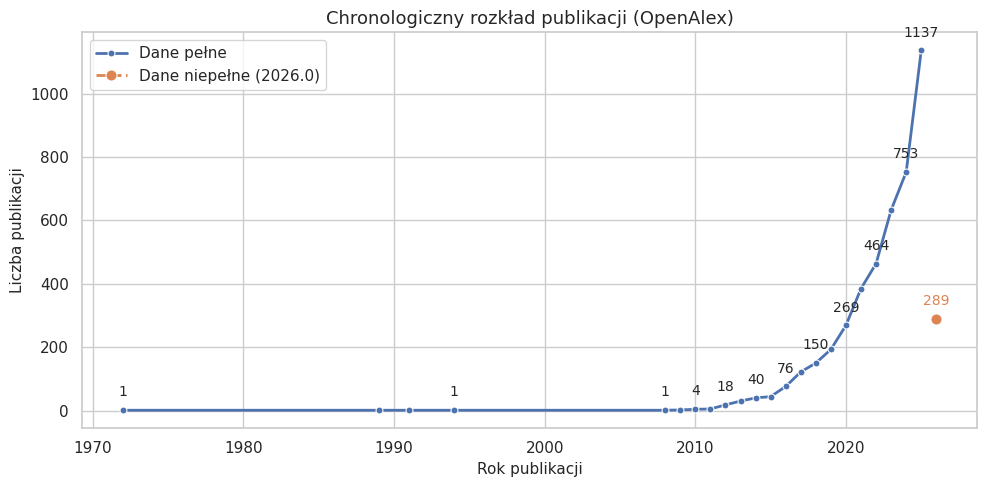

In [ ]:
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Ostatni rok w danych
last_year = yearly_counts_op.index.max()
# Dane pełne, but exclude 2026
yc_full = yearly_counts_op[yearly_counts_op.index < last_year]
# Dane niepełne (ostatni rok)
yc_partial = yearly_counts_op[yearly_counts_op.index == last_year]

fig, ax = plt.subplots(figsize=(10, 5))

# Linia dla danych pełnych
sns.lineplot(
    x=yc_full.index, y=yc_full.values,
    marker="o", linewidth=2, markersize=5,
    label="Dane pełne", ax=ax
)

# Linia dla danych niepełnych (ostatni rok)
sns.lineplot(
    x=yc_partial.index, y=yc_partial.values,
    marker="o", markersize=8, linewidth=2, linestyle="--",
    label=f"Dane niepełne ({last_year})", ax=ax
)

# --- Etykiety wartości co 2 lata ---
offset = (max(yc_full.values) * 0.03)  # 3% wysokości — wyraźnie wyżej

for x, y in zip(yc_full.index, yc_full.values):
    if x % 2 == 0 or x == 2025:  # Etykiety co 2 lata lub dla ostatniego roku
        ax.text(
            x, y + offset,
            str(y), ha='center', va='bottom',
            fontsize=10
        )

# --- Etykieta dla ostatniego roku ---
for x, y in zip(yc_partial.index, yc_partial.values):
    ax.text(
        x, y + offset,
        str(y), ha='center', va='bottom',
        fontsize=10, color=sns.color_palette()[1]
    )

ax.set(title='Chronologiczny rozkład publikacji (OpenAlex)',
       xlabel='Rok publikacji', ylabel='Liczba publikacji')
ax.legend()
fig.tight_layout()
plt.show()

<Axes: xlabel='publication_year'>

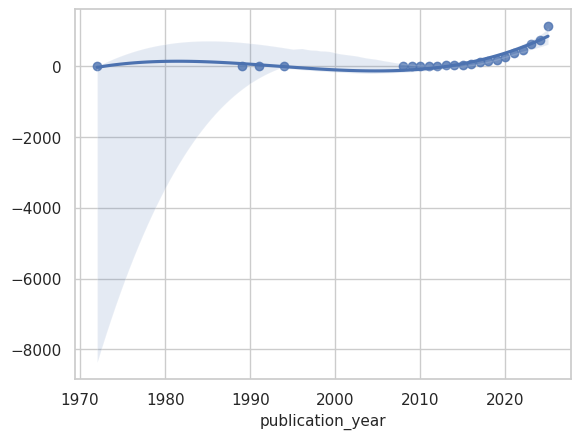

In [28]:
sns.regplot(x=yc_full.index, y=yc_full.values, data=yc_full, order=3)


RuntimeError: `lowess=True` requires statsmodels, an optional dependency, to be installed.

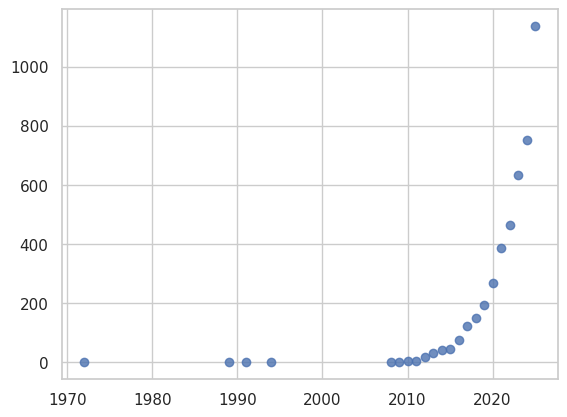

In [30]:
sns.regplot(x=yc_full.index, y=yc_full.values, data=yc_full,lowess = True)

In [39]:
yc_full.head()

publication_year
1972.0    1
1989.0    1
1991.0    1
1994.0    1
2008.0    1
Name: count, dtype: object

In [ ]:
yc_full['log_y'] = np.log1p(df_ap['publication_year'].value_counts().sort_index())


df= df_ap['publication_year'].value_counts().sort_index()



In [52]:

df_ap['log_y'] = np.log1p(df_ap['publication_year'])
df_ap['log_y'] 

0       7.610853
1       7.608871
2       7.611348
3       7.608871
4       7.611842
          ...   
4628    7.612831
4629    7.612831
4630    7.613819
4631    7.613819
4632    7.613819
Name: log_y, Length: 4633, dtype: float64

C:\Users\geraa\AppData\Local\Temp\ipykernel_30632\1739627119.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([int(np.expm1(t)) for t in ticks])


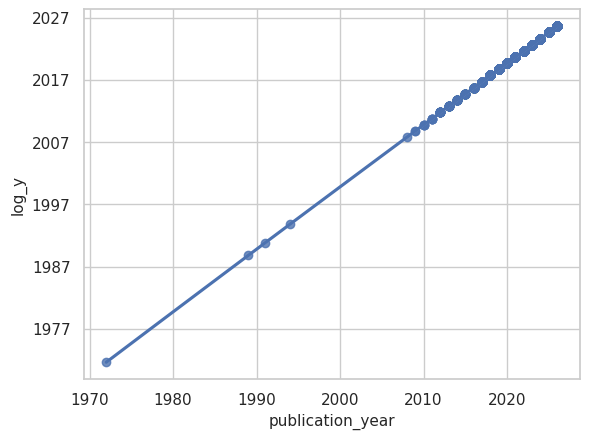

In [56]:
ax = sns.regplot(data=df_ap, x='publication_year', y='log_y', order=3)
ticks = ax.get_yticks()
ax.set_yticklabels([int(np.expm1(t)) for t in ticks])
plt.show()

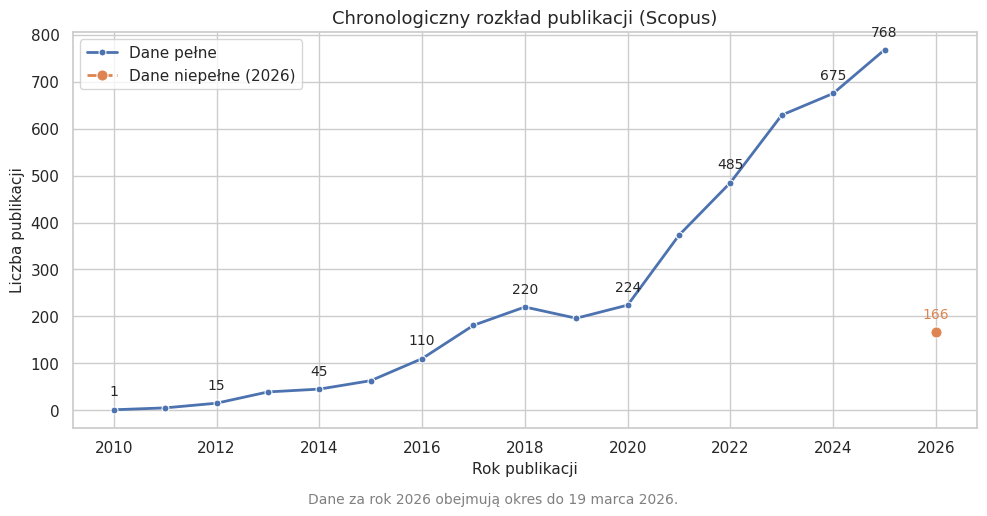

In [18]:
# Dane Scopus
yearly_counts_sc = df_sc['Year'].value_counts().sort_index()

# Ostatni rok
last_year_sc = yearly_counts_sc.index.max()

# Dane pełne i niepełne
sc_full = yearly_counts_sc[yearly_counts_sc.index < last_year_sc]
sc_partial = yearly_counts_sc[yearly_counts_sc.index == last_year_sc]

fig, ax = plt.subplots(figsize=(10, 5))

# Linia dla danych pełnych
sns.lineplot(
    x=sc_full.index, y=sc_full.values,
    marker="o", linewidth=2, markersize=5,
    label="Dane pełne", ax=ax
)

# Linia dla danych niepełnych
sns.lineplot(
    x=sc_partial.index, y=sc_partial.values,
    marker="o", markersize=8, linewidth=2, linestyle="--",
    label=f"Dane niepełne ({last_year_sc})", ax=ax
)

# Offset etykiet (3% wysokości)
offset_sc = max(sc_full.values) * 0.03

# --- Etykiety wartości co 2 lata ---
for x, y in zip(sc_full.index, sc_full.values):
    if x % 2 == 0 or x == 2025:  # Etykiety co 2 lata lub dla ostatniego roku
        ax.text(
            x, y + offset_sc,
            str(y), ha='center', va='bottom',
            fontsize=10
        )

# Etykieta dla ostatniego roku
for x, y in zip(sc_partial.index, sc_partial.values):
    ax.text(
        x, y + offset_sc,
        str(y), ha='center', va='bottom',
        fontsize=10, color=sns.color_palette()[1]
    )

# Informacja o niepełnym roku
fig.text(
    0.5, -0.02,
    "Dane za rok 2026 obejmują okres do 19 marca 2026.",
    ha='center', fontsize=10, color='gray'
)

ax.set(title='Chronologiczny rozkład publikacji (Scopus)',
       xlabel='Rok publikacji', ylabel='Liczba publikacji')
ax.legend()
fig.tight_layout()
plt.show()

<Axes: xlabel='Year'>

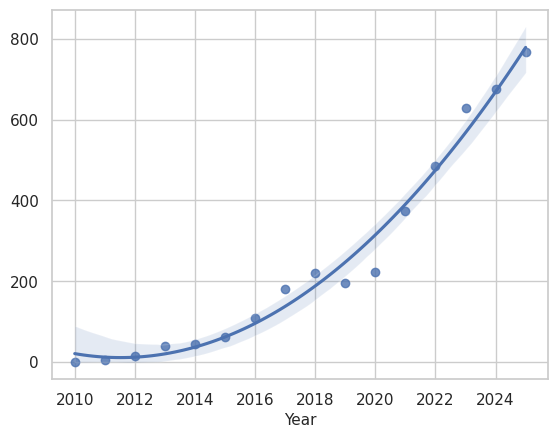

In [59]:
sns.regplot(x=sc_full.index, y=sc_full.values, data=sc_full, order=2)

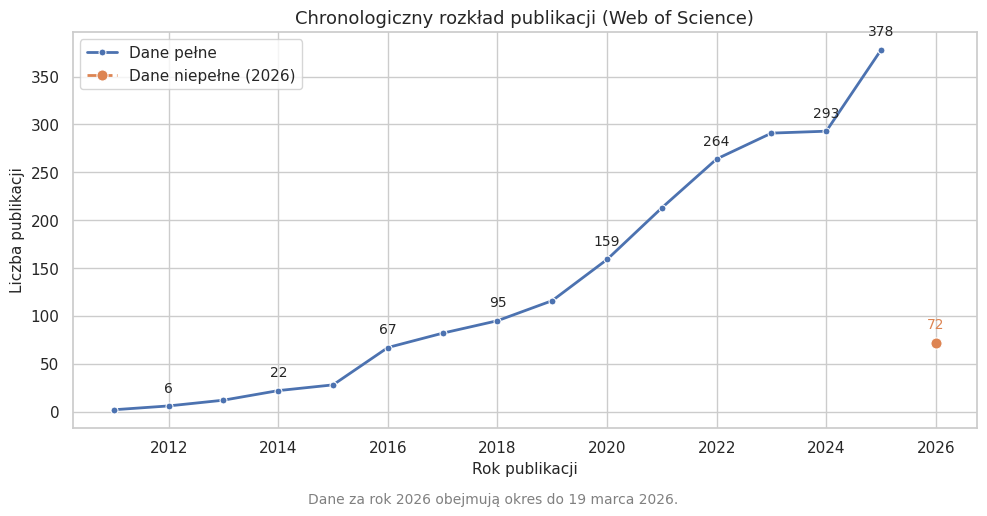

In [20]:
# Dane Web of Science
yearly_counts_wof = df_wos['Year Published'].value_counts().sort_index()

# Ostatni rok
last_year_wof = yearly_counts_wof.index.max()

# Dane pełne i niepełne
wof_full = yearly_counts_wof[yearly_counts_wof.index < last_year_wof]
wof_partial = yearly_counts_wof[yearly_counts_wof.index == last_year_wof]

fig, ax = plt.subplots(figsize=(10, 5))

# Linia dla danych pełnych
sns.lineplot(
    x=wof_full.index, y=wof_full.values,
    marker="o", linewidth=2, markersize=5,
    label="Dane pełne", ax=ax
)

# Linia dla danych niepełnych
sns.lineplot(
    x=wof_partial.index, y=wof_partial.values,
    marker="o", markersize=8, linewidth=2, linestyle="--",
    label=f"Dane niepełne ({last_year_wof})", ax=ax
)

# Offset etykiet (3% wysokości)
offset_wof = max(wof_full.values) * 0.03

# Etykiety co 2 lata
for x, y in zip(wof_full.index, wof_full.values):
    if x % 2 == 0 or x == 2025:  # Etykiety co 2 lata lub dla ostatniego roku
        ax.text(
            x, y + offset_wof,
            str(y), ha='center', va='bottom', fontsize=10
        )

# Etykieta dla ostatniego roku
for x, y in zip(wof_partial.index, wof_partial.values):
    ax.text(
        x, y + offset_wof,
        str(y), ha='center', va='bottom',
        fontsize=10, color=sns.color_palette()[1]
    )

# Informacja o niepełnym roku
fig.text(
    0.5, -0.02,
    "Dane za rok 2026 obejmują okres do 19 marca 2026.",
    ha='center', fontsize=10, color='gray'
)

ax.set(title='Chronologiczny rozkład publikacji (Web of Science)',
       xlabel='Rok publikacji', ylabel='Liczba publikacji')
ax.legend()
fig.tight_layout()
plt.show()

<Axes: xlabel='Year Published'>

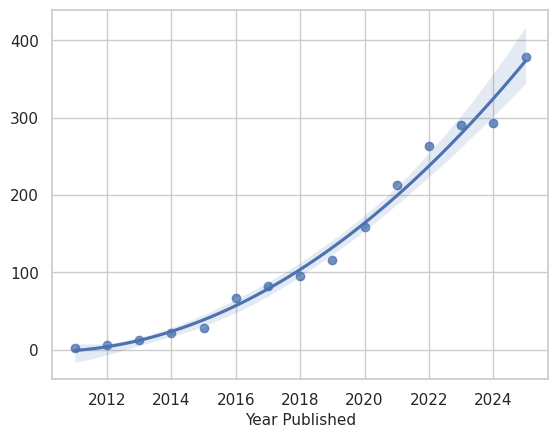

In [62]:
sns.regplot(x=wof_full.index, y=wof_full.values, data=wof_full, order=2)

## Rozkład geograficzny publikacji, recenzji, artykułów naukowych dotyczących tematu zarejestrowanych w bazach danych 


In [ ]:
# Open Alex
df_ap_coun = df_ap['authorships.countries']
df_ap_coun = df_ap_coun.dropna()
df_ap_coun.head()


0                      BD|BD|BD
1                         IN|IN
2    US|US|US|US|US|US|US|US|US
3                         IN|IN
4            BD|BD||BD|BD|BD|BD
Name: authorships.countries, dtype: str

In [ ]:
# funkcja do rozdzielenia ciągu znaków po seperatorze '|'
def clean_and_get_unique_countries(text):
    codes = str(text).split('|')
    
    unique_codes = set([code.strip() for code in codes if code.strip() != ''])
    
    return list(unique_codes)

In [ ]:
df_ap_coun = df_ap_coun.apply(clean_and_get_unique_countries)
print(df_ap_coun.head())

0    [BD]
1    [IN]
2    [US]
3    [IN]
4    [BD]
Name: authorships.countries, dtype: object


In [ ]:
country_counts = df_ap_coun.explode().value_counts()
print(country_counts.head(10))
# add human-readable names of countries

authorships.countries
IN    773
US    668
CN    281
GB    179
ID    165
DE    127
ES    102
BD     89
SA     88
CA     86
Name: count, dtype: int64


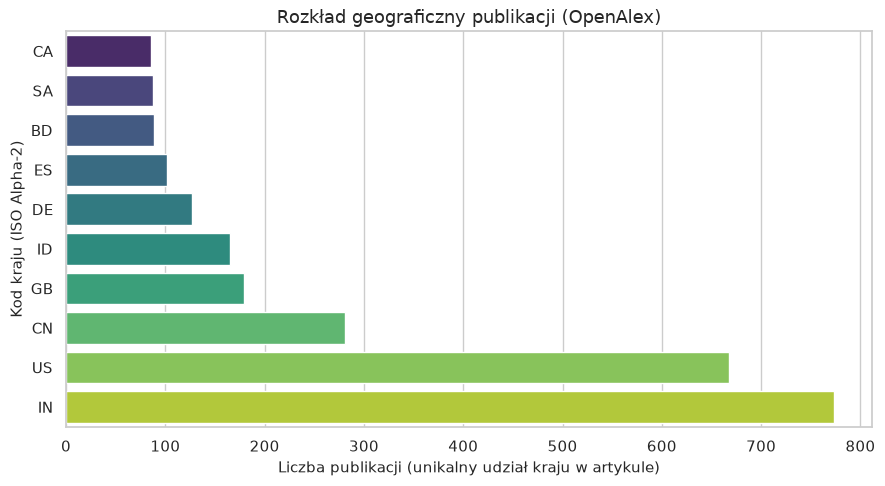

In [ ]:
top = country_counts.head(10).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=top.values, y=top.index, hue=top.index,
            palette="viridis", legend=False, ax=ax)
ax.set(title='Rozkład geograficzny publikacji (OpenAlex)',
       xlabel='Liczba publikacji (unikalny udział kraju w artykule)',
       ylabel='Kod kraju (ISO Alpha-2)')
fig.tight_layout()
plt.show()

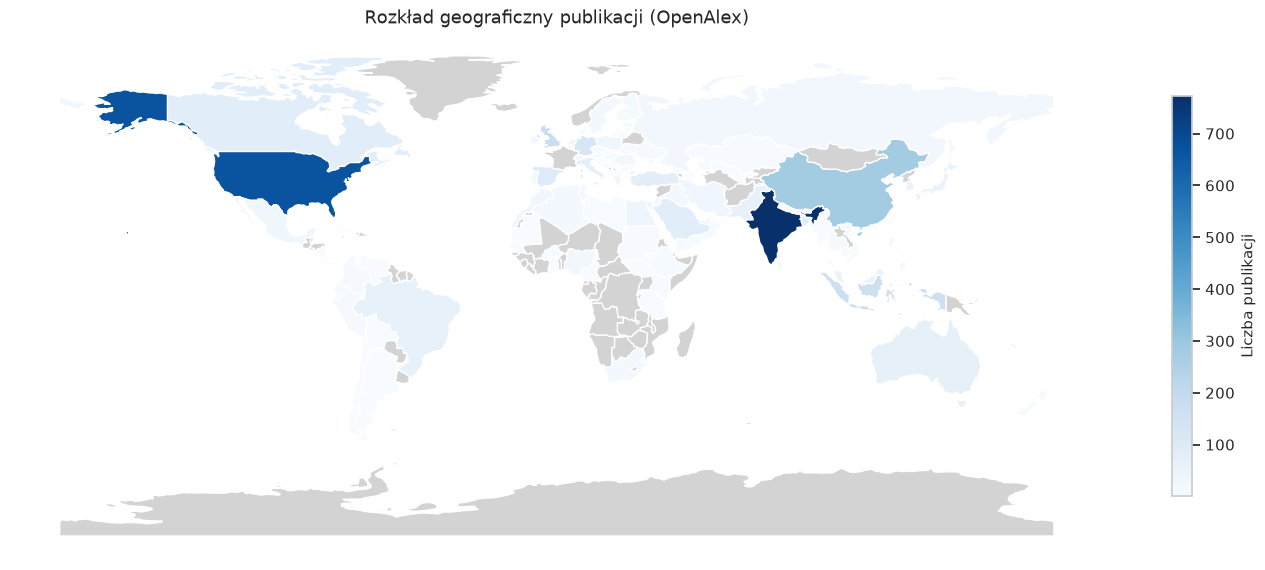

In [ ]:
import geopandas as gpd
import pycountry
import matplotlib.pyplot as plt

def alpha2_to_alpha3(code):
    try:
        return pycountry.countries.get(alpha_2=code).alpha_3
    except Exception:
        return None

country_df = country_counts.reset_index()
country_df.columns = ['country_code', 'count']
country_df['iso_a3'] = country_df['country_code'].apply(alpha2_to_alpha3)
country_df = country_df.dropna(subset=['iso_a3'])

url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)[['ISO_A3', 'geometry']].rename(columns={'ISO_A3': 'iso_a3'})
world_merged = world.merge(country_df, on='iso_a3', how='left')

fig, ax = plt.subplots(figsize=(14, 7))
world_merged.plot(
    column='count',
    ax=ax,
    cmap='Blues',
    legend=True,
    missing_kwds={'color': 'lightgrey'},
    legend_kwds={'label': 'Liczba publikacji', 'shrink': 0.6}
)
ax.set_title('Rozkład geograficzny publikacji (OpenAlex)')
ax.axis('off')
plt.tight_layout()
plt.show()

In [77]:
# Scopus
df_sc['Affiliations'][0]

'Avinashilingam Institute for Home Science and Higher Education for Women, India'

In [76]:
#Funkcja wyciągająca nazwy krajów z  Scopus
def get_countries(affiliation_text):
    affiliations = str(affiliation_text).split(';')

    unique_countries = set()
    
    for aff in affiliations:
        parts = aff.split(',')
        if len(parts) > 0:
            country = parts[-1].strip() 
            if country and not country.isdigit():
                unique_countries.add(country)
                
    return list(unique_countries)

In [78]:
df_sc_coun = df_sc['Affiliations']
df_sc_coun = df_sc_coun.dropna()
df_sc_coun.head()


0    Avinashilingam Institute for Home Science and ...
1    Mathematics and Mechanics, St Petersburg State...
2    Laboratory LIMATI, Polydisciplinary Faculty, S...
3    Clinical, Educational and Health Psychology, U...
4    Department of Allied and Public Health, School...
Name: Affiliations, dtype: object

In [79]:
df_sc_coun = df_sc_coun.apply(get_countries)
df_sc_coun.head()

0                                [India]
1    [United States, Russian Federation]
2                              [Morocco]
3                       [United Kingdom]
4                [India, United Kingdom]
Name: Affiliations, dtype: object

0                                                 [India]
1                     [United States, Russian Federation]
2                                               [Morocco]
3                                        [United Kingdom]
4                                 [India, United Kingdom]
                              ...                        
4190                                              [China]
4191                                              [Spain]
4192    [Computer Science, iSchool, Linguistics, Unite...
4193                                              [Spain]
4194                                              [Japan]
Name: Affiliations, Length: 4118, dtype: object


In [100]:
scopus_country_counts = scopus_country_counts.rename(index=lambda x: 'USA' if 'United States' in str(x) else x)

print(scopus_country_counts.head(10))

Affiliations
India             1199
USA                695
China              345
United Kingdom     228
Spain              173
Saudi Arabia       171
Canada             122
Pakistan           117
Bangladesh         103
Italy              102
Name: count, dtype: int64


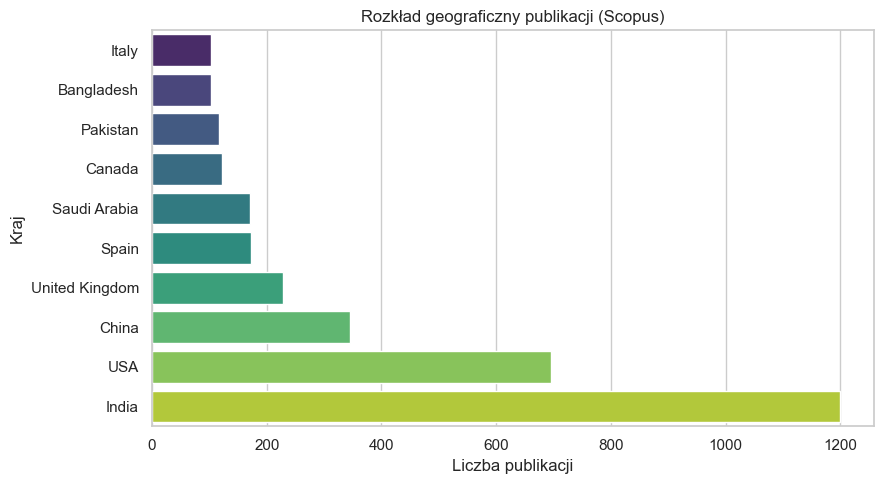

In [101]:
top = scopus_country_counts.head(10).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=top.values, y=top.index, hue=top.index,
            palette="viridis", legend=False, ax=ax)
ax.set(title='Rozkład geograficzny publikacji (Scopus)',
       xlabel='Liczba publikacji',
       ylabel='Kraj')
fig.tight_layout()
plt.show()

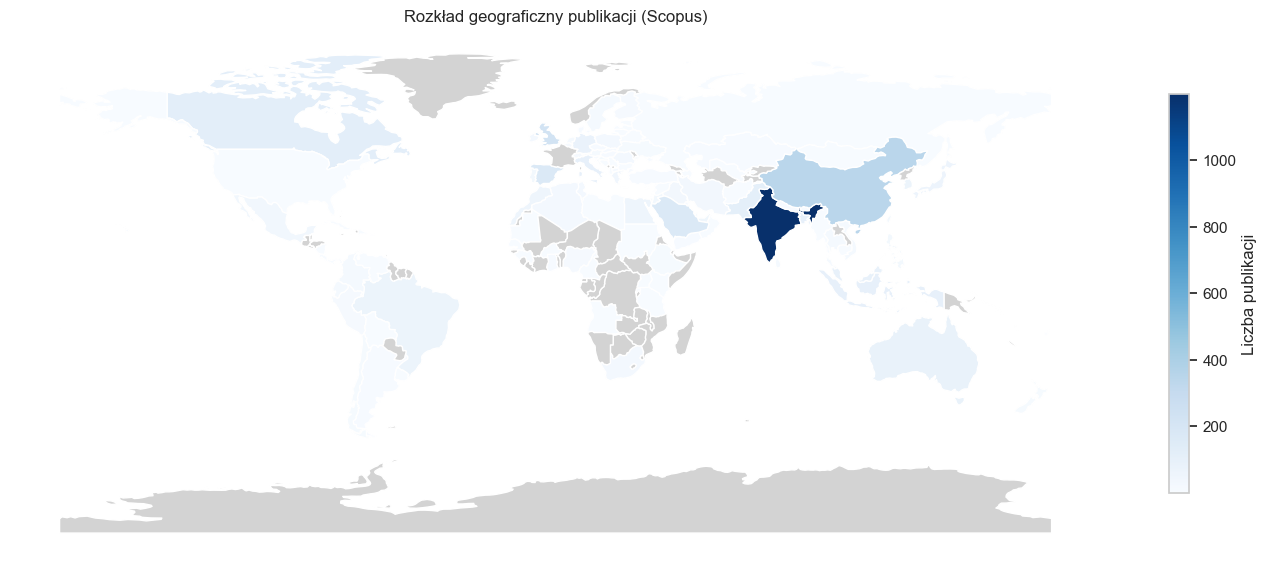

In [102]:
import geopandas as gpd
import pycountry
import matplotlib.pyplot as plt

def name_to_alpha3(name):
    try:
        return pycountry.countries.search_fuzzy(name)[0].alpha_3
    except Exception:
        return None

scopus_df = scopus_country_counts.reset_index()
scopus_df.columns = ['country_name', 'count']
scopus_df['iso_a3'] = scopus_df['country_name'].apply(name_to_alpha3)
scopus_df = scopus_df.dropna(subset=['iso_a3'])

url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)[['ISO_A3', 'geometry']].rename(columns={'ISO_A3': 'iso_a3'})
world_merged = world.merge(scopus_df, on='iso_a3', how='left')

fig, ax = plt.subplots(figsize=(14, 7))
world_merged.plot(
    column='count',
    ax=ax,
    cmap='Blues',
    legend=True,
    missing_kwds={'color': 'lightgrey'},
    legend_kwds={'label': 'Liczba publikacji', 'shrink': 0.6}
)
ax.set_title('Rozkład geograficzny publikacji (Scopus)')
ax.axis('off')
plt.tight_layout()
plt.show()

In [11]:
df_wos.columns

Index(['Publication Type', 'Authors', 'Book Authors', 'Editors',
       'Book Group Authors', 'Author Full Name', 'Book Authors Full Name',
       'Group Authors', 'Document Title', 'Publication Name',
       'Book Series Title', 'Book Series Subtitle', 'Language',
       'Document Type', 'Conference Title', 'Conference Date',
       'Conference Location', 'Conference Sponsors', 'Conference Host',
       'Author Keywords', 'Keywords Plus®', 'Abstract', 'Author Address', 'C3',
       'Reprint Address', 'E-mail Address', 'ResearcherID Number',
       'ORCID Identifier (Open Researcher and Contributor ID)',
       'Funding Agency and Grant Number', 'FP', 'Funding Text',
       'Cited References', 'Cited Reference Count',
       'Web of Science Core Collection Times Cited Count',
       'Total Times Cited Count', 'Usage Count (Last 180 Days)',
       'Usage Count (Since 2013)', 'Publisher', 'Publisher City',
       'Publisher Address', 'International Standard Serial Number (ISSN)',
       

In [54]:
# Web of Science

df_wos_coun = df_wos['Author Address']
df_wos_coun = df_wos_coun.dropna()
df_wos_coun


0       [Molenaar, Annika; Jenkins, Eva L.; McCaffrey,...
1       [Arya, Vishakha; Mishra, Amit Kumar] DIT Univ,...
2       [Albahli, Saleh] Qassim Univ, Coll Comp, Dept ...
3       [Rivadeneira, Lucia; Loor, Ignacio] Univ Tecn ...
4       [El Ouahabi, Sara; Dadil, El Wardani] Abdelmal...
                              ...                        
2094    [Ayers, John W.; Caputi, Theodore L.] Univ Cal...
2095    [Klein, Ari Z.] Univ Penn, Perelman Sch Med, D...
2096    [Chae, Seung Woo] Indiana Univ, Luddy Sch Info...
2097    [Cummins, Jack Alexander] Manchester Essex Reg...
2098    [Rajalingam, Karan] Florida Atlantic Univ, Cha...
Name: Author Address, Length: 2096, dtype: object

In [55]:

def get_wos_countries(address_text):
    if pd.isna(address_text):
        return []
        
    text = str(address_text)
    text_no_authors = re.sub(r'\[.*?\]', '', text)
    affiliations = text_no_authors.split(';')
    
    unique_countries = set()
    for aff in affiliations:
        aff = aff.strip()
        if not aff:
            continue
            
        aff_cleaned = aff.rstrip('.')
        words = aff_cleaned.split()
        if words:
            country = words[-1].strip()
            
            if 'Peoples R China' in aff:
                country = 'China'
                
            if country and not country.isdigit():

                unique_countries.add(country)
                
    return list(unique_countries)


In [56]:
df_wos_coun['Country'] = df_wos_coun.apply(get_wos_countries)
df_wos_coun['Country'].head()

0       [Australia]
1    [Spain, India]
2          [Arabia]
3         [Ecuador]
4         [Morocco]
Name: Author Address, dtype: object

In [57]:
wos_country_counts = df_wos_coun['Country'].explode().value_counts()
print("Top 10 państw w bazie Web of Science:")
print(wos_country_counts.head(10))

Top 10 państw w bazie Web of Science:
Author Address
USA          504
India        300
China        238
Spain        139
England      137
Arabia       117
Canada        82
Pakistan      81
Australia     77
Italy         77
Name: count, dtype: int64


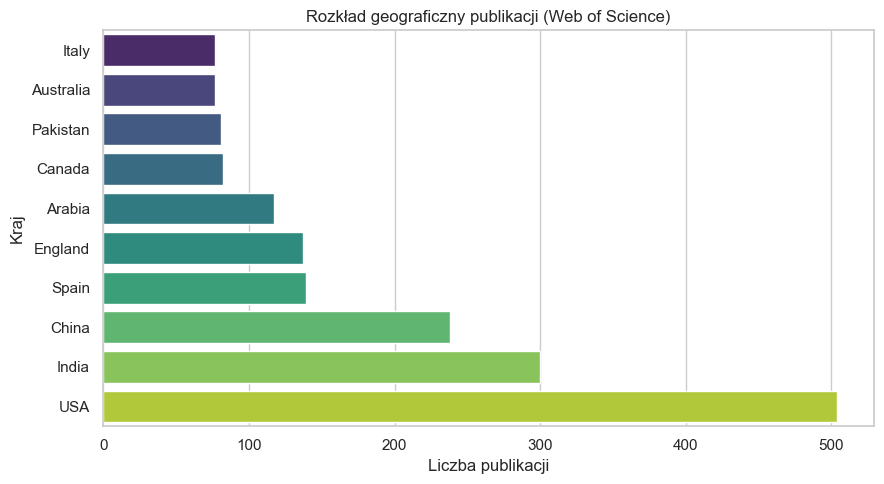

In [49]:
top = wos_country_counts.head(10).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=top.values, y=top.index, hue=top.index,
            palette="viridis", legend=False, ax=ax)
ax.set(title='Rozkład geograficzny publikacji (Web of Science)',
       xlabel='Liczba publikacji',
       ylabel='Kraj')
fig.tight_layout()
plt.show()

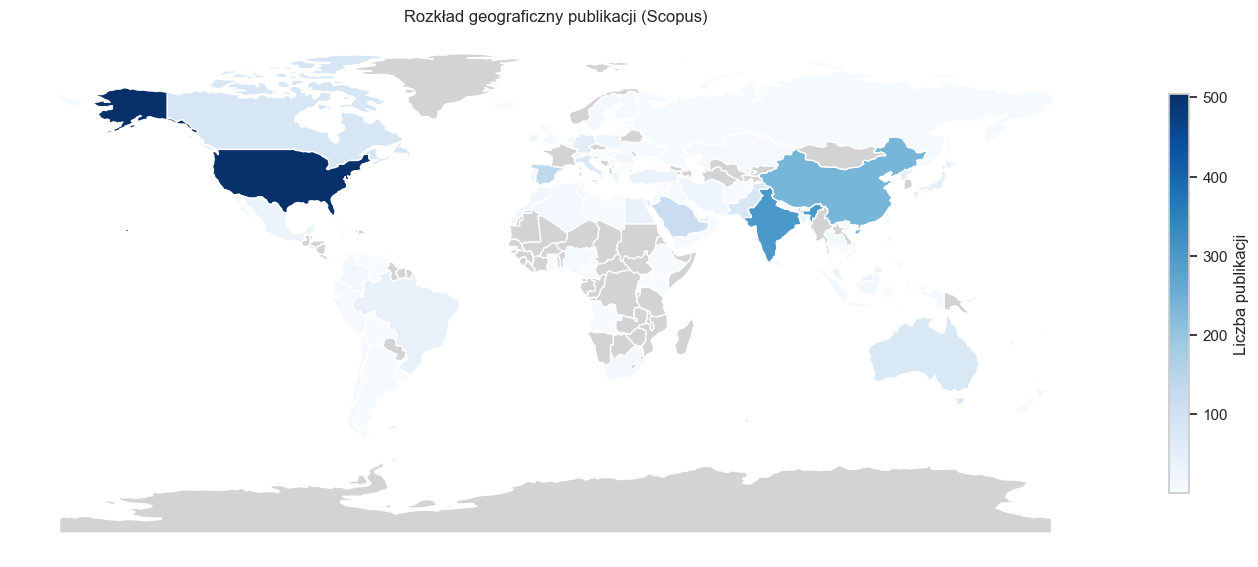

In [68]:
import geopandas as gpd
import pycountry
import matplotlib.pyplot as plt

def name_to_alpha3(name):
    try:
        return pycountry.countries.search_fuzzy(name)[0].alpha_3
    except Exception:
        return None

scopus_df = wos_country_counts.reset_index()
scopus_df.columns = ['country_name', 'count']
scopus_df['iso_a3'] = scopus_df['country_name'].apply(name_to_alpha3)
scopus_df = scopus_df.dropna(subset=['iso_a3'])

url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)[['ISO_A3', 'geometry']].rename(columns={'ISO_A3': 'iso_a3'})
world_merged = world.merge(scopus_df, on='iso_a3', how='left')

fig, ax = plt.subplots(figsize=(14, 7))
world_merged.plot(
    column='count',
    ax=ax,
    cmap='Blues',
    legend=True,
    missing_kwds={'color': 'lightgrey'},
    legend_kwds={'label': 'Liczba publikacji', 'shrink': 0.6}
)
ax.set_title('Rozkład geograficzny publikacji (Scopus)')
ax.axis('off')
plt.tight_layout()
plt.show()

## Rozkład tematu według dyscyplin naukowych


In [ ]:
# Open Alex
df_op_areas = df_ap['primary_topic.display_name'].dropna().value_counts()

print("Top 10 dziedzin w OpenAlex:")
print(df_op_areas.head(10))

Top 10 dziedzin w OpenAlex:
primary_topic.display_name
Sentiment Analysis and Opinion Mining        1377
Misinformation and Its Impacts                275
Mental Health via Writing                     198
Hate Speech and Cyberbullying Detection       189
Topic Modeling                                108
Stock Market Forecasting Methods               99
Digital Marketing and Social Media             97
Public Relations and Crisis Communication      95
Social Media and Politics                      87
Complex Network Analysis Techniques            72
Name: count, dtype: int64


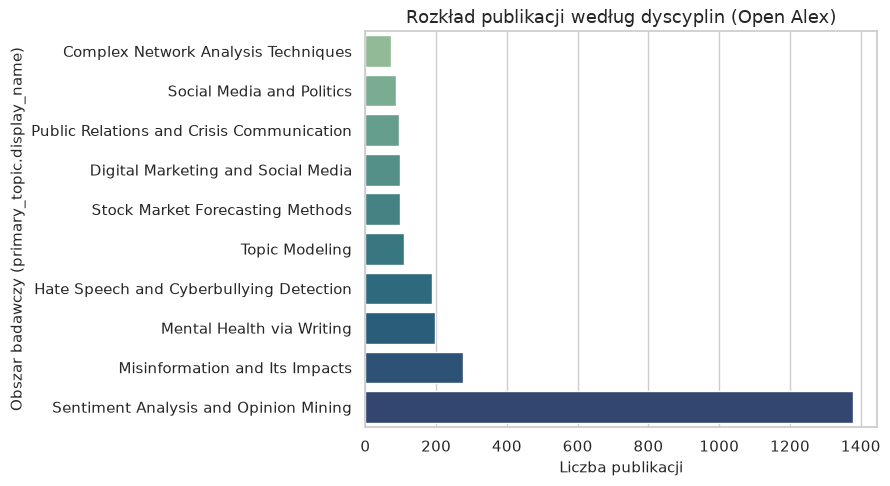

In [ ]:
top = df_op_areas.head(10).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=top.values, y=top.index, hue=top.index,
            palette="crest", legend=False, ax=ax)
ax.set(title='Rozkład publikacji według dyscyplin (Open Alex)',
       xlabel='Liczba publikacji',
       ylabel='Obszar badawczy (primary_topic.display_name)')
fig.tight_layout()
plt.show()

In [ ]:
df_sc.columns 

Index(['Authors', 'Author full names', 'Author(s) ID', 'Title', 'Year',
       'Source title', 'Volume', 'Issue', 'Art. No.', 'Page start', 'Page end',
       'Cited by', 'DOI', 'Link', 'Affiliations', 'Authors with affiliations',
       'Abstract', 'Author Keywords', 'Index Keywords',
       'Molecular Sequence Numbers', 'Chemicals/CAS', 'Tradenames',
       'Manufacturers', 'Funding Details', 'Funding Texts', 'References',
       'Correspondence Address', 'Editors', 'Publisher', 'Sponsors',
       'Conference name', 'Conference date', 'Conference location',
       'Conference code', 'ISSN', 'ISBN', 'CODEN', 'PubMed ID',
       'Language of Original Document', 'Abbreviated Source Title',
       'Document Type', 'Publication Stage', 'Open Access', 'Source', 'EID'],
      dtype='object')

In [ ]:
# Scopus
df_sc_areas = df_sc['Source title'].dropna().value_counts()# Find Publisher and find their domain
print("Top 10 dziedzin w Scopus:")
print(df_sc_areas.head(10))

Top 10 dziedzin w Scopus:
Source title
Lecture Notes in Networks and Systems                                                                                                   163
Lecture Notes in Computer Science (including subseries Lecture Notes in Artificial Intelligence and Lecture Notes in Bioinformatics)    137
CEUR Workshop Proceedings                                                                                                                97
Communications in Computer and Information Science                                                                                       94
Journal of Medical Internet Research                                                                                                     81
IEEE Access                                                                                                                              68
ACM International Conference Proceeding Series                                                                           

C:\Users\mmakr\AppData\Local\Temp\ipykernel_14820\136970634.py:8: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


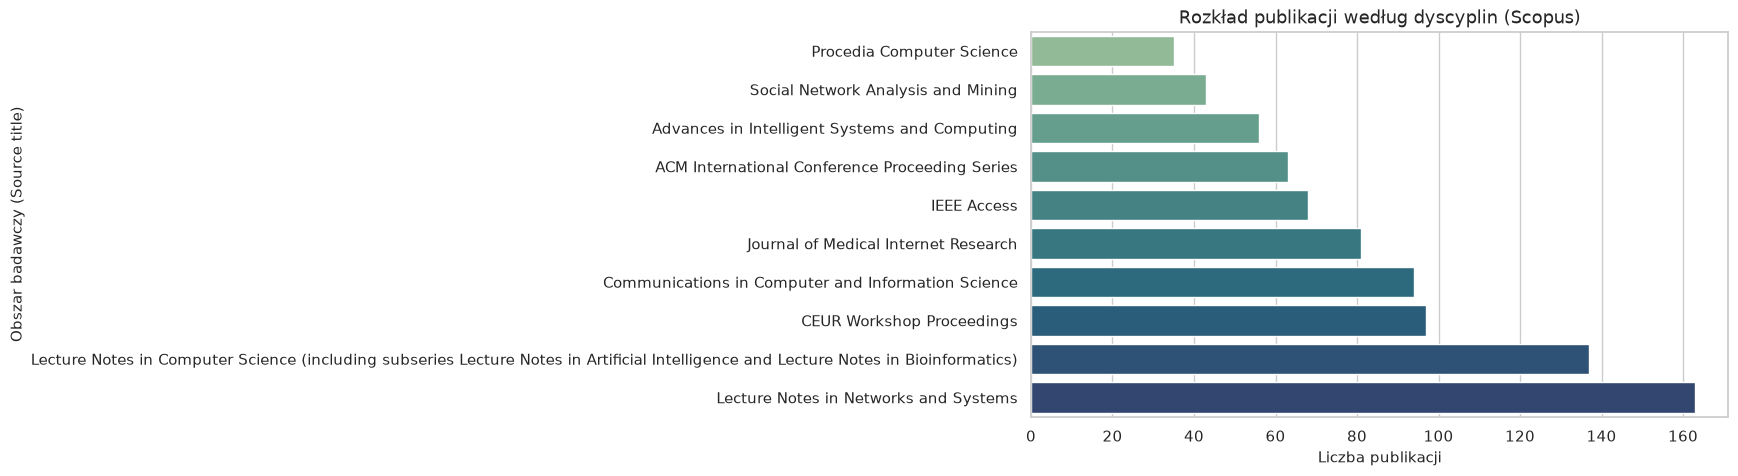

In [ ]:
top = df_sc_areas.head(10).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=top.values, y=top.index, hue=top.index,
            palette="crest", legend=False, ax=ax)
ax.set(title='Rozkład publikacji według dyscyplin (Scopus)',
       xlabel='Liczba publikacji',
       ylabel='Obszar badawczy (Source title)')
fig.tight_layout()
plt.show()

In [ ]:
df_wos.columns # same as SCOPUS, use Publisher column

Index(['Publication Type', 'Authors', 'Book Authors', 'Editors',
       'Book Group Authors', 'Author Full Name', 'Book Authors Full Name',
       'Group Authors', 'Document Title', 'Publication Name',
       'Book Series Title', 'Book Series Subtitle', 'Language',
       'Document Type', 'Conference Title', 'Conference Date',
       'Conference Location', 'Conference Sponsors', 'Conference Host',
       'Author Keywords', 'Keywords Plus®', 'Abstract', 'Author Address', 'C3',
       'Reprint Address', 'E-mail Address', 'ResearcherID Number',
       'ORCID Identifier (Open Researcher and Contributor ID)',
       'Funding Agency and Grant Number', 'FP', 'Funding Text',
       'Cited References', 'Cited Reference Count',
       'Web of Science Core Collection Times Cited Count',
       'Total Times Cited Count', 'Usage Count (Last 180 Days)',
       'Usage Count (Since 2013)', 'Publisher', 'Publisher City',
       'Publisher Address', 'International Standard Serial Number (ISSN)',
       

In [ ]:
# Web of Science
df_wos_areas = df_wos['Research Areas']
df_wos_areas.dropna()
df_wos_areas.head()

0                          Nutrition & Dietetics
1                               Computer Science
2    Public, Environmental & Occupational Health
3                                  Communication
4                               Computer Science
Name: Research Areas, dtype: str

In [ ]:
# funkcja na podzielenie dziedzin 
def get_wos_areas(area_text):
    areas = str(area_text).split(';')
    return [area.strip() for area in areas if area.strip() != '']

In [ ]:
df_wos_areas = df_wos_areas.apply(get_wos_areas)
wos_areas_counts = df_wos_areas.explode().value_counts()
print("Top 10 dziedzin w Web of Science: ")
print(wos_areas_counts.head(10))

Top 10 dziedzin w Web of Science: 
Research Areas
Computer Science                               1180
Engineering                                     388
Telecommunications                              169
Health Care Sciences & Services                 148
Medical Informatics                             133
Science & Technology - Other Topics             111
Business & Economics                             86
Public, Environmental & Occupational Health      76
Information Science & Library Science            73
Linguistics                                      62
Name: count, dtype: int64


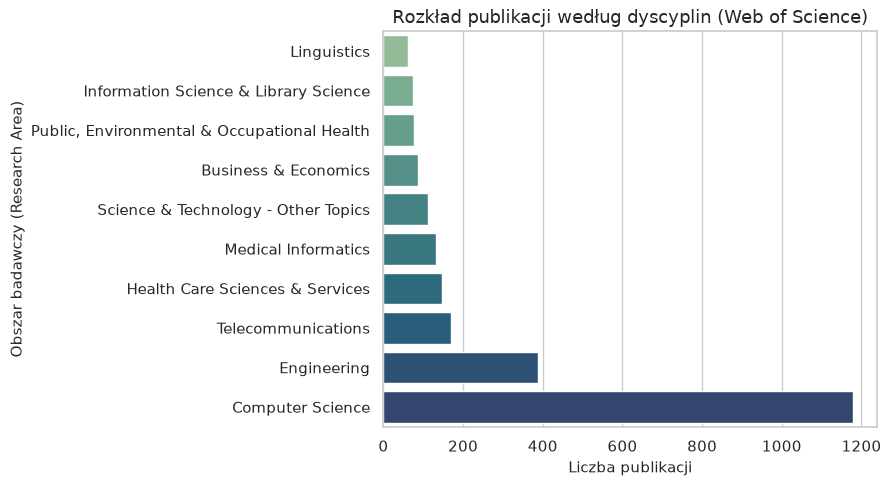

In [ ]:
top = wos_areas_counts.head(10).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=top.values, y=top.index, hue=top.index,
            palette="crest", legend=False, ax=ax)
ax.set(title='Rozkład publikacji według dyscyplin (Web of Science)',
       xlabel='Liczba publikacji',
       ylabel='Obszar badawczy (Research Area)')
fig.tight_layout()
plt.show()

## Rozkład wg języków publikacji


In [ ]:

oa_lang_counts = df_ap['language'].dropna().value_counts().head(10)
sc_lang_counts = df_sc['Language of Original Document'].dropna().value_counts().head(10)
wos_lang_counts = df_wos['Language'].dropna().value_counts().head(10)


In [ ]:

print("Top 5 języków (Open Alex)")
print(oa_lang_counts.head(5))
print("Top 5 języków (Scopus)")
print(sc_lang_counts.head(5))
print("Top 5 języków (Web of Science)")
print(wos_lang_counts.head(5))

Top 5 języków (Open Alex)
language
en     4030
es       12
id       11
fr        6
enc       4
Name: count, dtype: int64
Top 5 języków (Scopus)
Language of Original Document
English       4128
Chinese         20
Spanish         19
Turkish         10
Portuguese       8
Name: count, dtype: int64
Top 5 języków (Web of Science)
Language
English       2078
Spanish         12
Turkish          7
Portuguese       1
Russian          1
Name: count, dtype: int64


## Liczba publikacji

In [ ]:
total_openalex = len(df_ap)
total_scopus = len(df_sc)
total_wos = len(df_wos)

In [ ]:

print("PODSUMOWANIE CAŁKOWITEJ LICZBY PUBLIKACJI ")
print(f"OpenAlex:        {total_openalex}")
print(f"Scopus:          {total_scopus}")
print(f"Web of Science:  {total_wos}")


PODSUMOWANIE CAŁKOWITEJ LICZBY PUBLIKACJI 
OpenAlex:        4633
Scopus:          4195
Web of Science:  2100


## liczba współpracujących autorów

In [69]:
# open alex
df_openalex_authors = df_ap['authorships.author.id'].dropna()
all_authors_openalex = df_openalex_authors.str.split(';').explode().str.strip()
openalex_unique_authors_count = all_authors_openalex.nunique()
openalex_avg_authors_per_paper = len(all_authors_openalex) / len(df_openalex_authors)
print(openalex_avg_authors_per_paper)

1.0


In [71]:
# scopus
df_scopus_authors = df_sc['Author(s) ID'].dropna()
all_authors_scopus = df_scopus_authors.str.split(';').explode().str.strip()
scopus_unique_authors_count = all_authors_scopus.nunique()
scopus_avg_authors_per_paper = len(all_authors_scopus) / len(df_scopus_authors)
print


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [72]:
# Web of science
df_wos_authors = df_wos['ORCID Identifier (Open Researcher and Contributor ID)'].dropna()
all_authors_wos = df_wos_authors.str.split(';').explode().str.strip()
wos_unique_authors_count = all_authors_wos.nunique()
wos_avg_authors_per_paper = len(all_authors_wos) / len(df_wos_authors)

In [73]:
print("Open ALex ")
print(f"Całkowita liczba współpracujących autorów (unikalnych): {openalex_unique_authors_count}")
print(f"Średnia liczba autorów na jedną publikację:            {openalex_avg_authors_per_paper:.2f}")

print("Scopus")
print(f"Całkowita liczba współpracujących autorów (unikalnych): {scopus_unique_authors_count}")
print(f"Średnia liczba autorów na jedną publikację:            {scopus_avg_authors_per_paper:.2f}")

print("Web of Science")
print(f"Całkowita liczba współpracujących autorów (unikalnych): {wos_unique_authors_count}")
print(f"Średnia liczba autorów na jedną publikację:            {wos_avg_authors_per_paper:.2f}")





Open ALex 
Całkowita liczba współpracujących autorów (unikalnych): 4026
Średnia liczba autorów na jedną publikację:            1.00
Scopus
Całkowita liczba współpracujących autorów (unikalnych): 13520
Średnia liczba autorów na jedną publikację:            3.78
Web of Science
Całkowita liczba współpracujących autorów (unikalnych): 3008
Średnia liczba autorów na jedną publikację:            2.37


In [74]:
print("Top 5 najbardzij płodnych autorów (Open Alex)")
print(all_authors_openalex.value_counts().head(5))

print("Top 5 najbardzij płodnych autorów (Scopus)")
print(all_authors_scopus.value_counts().head(5))
print("Top 5 najbardzij płodnych autorów (Web of Science)")
print(all_authors_wos.value_counts().head(5))

Top 5 najbardzij płodnych autorów (Open Alex)
authorships.author.id
https://openalex.org/A5037534749    49
||                                  31
|                                   27
||||                                27
|||                                 12
Name: count, dtype: int64
Top 5 najbardzij płodnych autorów (Scopus)
Author(s) ID
36976315000    15
57202222098    11
30067646600     9
55520653600     9
7103044028      9
Name: count, dtype: int64
Top 5 najbardzij płodnych autorów (Web of Science)
ORCID Identifier (Open Researcher and Contributor ID)
                                        318
Sarker, Abeed/0000-0001-7358-544X         9
Cambria, Erik/0000-0002-3030-1280         9
Valdez, Danny/0000-0002-2355-9881         8
Thakur, Nirmalya/0000-0002-3225-1870      8
Name: count, dtype: int64


## Wskaźnik produktywności na aktywne lata publikacji (Productivity per Active Year)

In [75]:

def calculate_productivity(name, years_series):
    if len(years_series) == 0:
        return None
    
    total_pub = len(years_series)
    active_years = years_series.nunique()
    
    productivity = total_pub / active_years
    
    return {
        "Base": name,
        "Total Publications": total_pub,
        "Active Years": active_years,
        "Productivity (Pub/Year)": round(productivity, 2)
    }



In [76]:
scopus_years = pd.to_numeric(df_sc['Year'], errors='coerce').dropna().astype(int)

wos_years = pd.to_numeric(df_wos['Year Published'], errors='coerce').dropna().astype(int)

oa_years = pd.to_numeric(df_ap['publication_year'], errors='coerce').dropna().astype(int)


In [77]:
productivit = []
productivit.append(calculate_productivity("Open Alex",oa_years))
productivit.append(calculate_productivity("Scopus",scopus_years))
productivit.append(calculate_productivity("Web of Science",wos_years))



In [78]:
print(productivit)

[{'Base': 'Open Alex', 'Total Publications': 4619, 'Active Years': 23, 'Productivity (Pub/Year)': 200.83}, {'Base': 'Scopus', 'Total Publications': 4195, 'Active Years': 17, 'Productivity (Pub/Year)': 246.76}, {'Base': 'Web of Science', 'Total Publications': 2100, 'Active Years': 16, 'Productivity (Pub/Year)': 131.25}]


In [79]:

df_productivity = pd.DataFrame([s for s in productivit if s is not None])

print("Productivity per Active Year")
print(df_productivity.to_string(index=False))

Productivity per Active Year
          Base  Total Publications  Active Years  Productivity (Pub/Year)
     Open Alex                4619            23                   200.83
        Scopus                4195            17                   246.76
Web of Science                2100            16                   131.25


## całkowita liczba cytowań (Total Citation Count)

In [ ]:
# OPEn Alex
oa_citations = pd.to_numeric(df_ap['cited_by_count'], errors='coerce').fillna(0)

total_cit_oa = oa_citations.sum()
avg_cit_oa = oa_citations.mean()


In [ ]:
# scopus

scopus_citations = pd.to_numeric(df_sc['Cited by'], errors='coerce').fillna(0)

total_cit_scopus = scopus_citations.sum()
avg_cit_scopus = scopus_citations.mean()


In [ ]:
# web of Science
wos_citations = pd.to_numeric(df_wos['Total Times Cited Count'], errors='coerce').fillna(0)

total_cit_wos = wos_citations.sum()
avg_cit_wos = wos_citations.mean()

In [ ]:
print(f"Analiza cytowań")
print(f"Open Alex - Suma cytowań:{int(total_cit_oa)}")
print(f"Open Alex - Średnia na artykuł: {int(avg_cit_oa)}")

print("-" * 30)
print(f"Scopus - Suma cytowań: {int(total_cit_scopus)}")
print(f"Scopus - Średnia na artykuł: {avg_cit_scopus:.2f}")
print("-" * 30)
print(f"WoS - Suma cytowań:{int(total_cit_wos)}")
print(f"WoS - Średnia na artykuł:{avg_cit_wos:.2f}")


Analiza cytowań
Open Alex - Suma cytowań:42275
Open Alex - Średnia na artykuł: 9
------------------------------
Scopus - Suma cytowań: 65312
Scopus - Średnia na artykuł: 15.57
------------------------------
WoS - Suma cytowań:39043
WoS - Średnia na artykuł:18.59
